#### Objectif : Construire un modèle de classification binaire qui prédit accord ou refus d'un crédit.


##### Collecte des données

In [3]:
# ============================================================
# ÉTAPE 2 — Collecte des données
# German Credit Dataset (UCI Machine Learning Repository)
# ============================================================

import pandas as pd
import numpy as np

# ---- Téléchargement direct depuis UCI ----
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

# Noms des colonnes (documentation officielle UCI)
colonnes = [
    "statut_compte",        # A1  : Statut du compte chèque
    "duree_mois",           # A2  : Durée du crédit (en mois)
    "historique_credit",    # A3  : Historique de crédit
    "objet_credit",         # A4  : Objet du crédit
    "montant_credit",       # A5  : Montant du crédit
    "epargne",              # A6  : Compte épargne / obligations
    "emploi_depuis",        # A7  : Emploi actuel depuis
    "taux_versement",       # A8  : Taux de versement (% du revenu)
    "statut_sexe",          # A9  : Statut personnel et sexe
    "autres_debiteurs",     # A10 : Autres débiteurs / garants
    "residence_depuis",     # A11 : Résidence actuelle depuis
    "propriete",            # A12 : Propriété
    "age",                  # A13 : Âge (en années)
    "autres_credits",       # A14 : Autres plans de crédit
    "logement",             # A15 : Logement
    "nb_credits",           # A16 : Nombre de crédits existants
    "emploi",               # A17 : Emploi
    "nb_personnes_charge",  # A18 : Nombre de personnes à charge
    "telephone",            # A19 : Téléphone
    "travailleur_etranger", # A20 : Travailleur étranger
    "cible"                 # Target : 1 = Bon client, 2 = Mauvais client
]

# Chargement
df = pd.read_csv(url, sep=" ", header=None, names=colonnes)

# Conversion de la cible : 1 = accord (bon), 0 = refus (mauvais)
df["cible"] = df["cible"].map({1: 1, 2: 0})

print("✅ Dataset chargé avec succès !")
print(f"   Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n📊 Distribution de la cible :")
print(df["cible"].value_counts())
print(f"\n   → Taux d'accord  : {df['cible'].mean()*100:.1f}%")
print(f"   → Taux de refus  : {(1-df['cible'].mean())*100:.1f}%")

# Aperçu
print("\n🔍 Aperçu des 5 premières lignes :")
print(df.head())

✅ Dataset chargé avec succès !
   Dimensions : 1000 lignes × 21 colonnes

📊 Distribution de la cible :
cible
1    700
0    300
Name: count, dtype: int64

   → Taux d'accord  : 70.0%
   → Taux de refus  : 30.0%

🔍 Aperçu des 5 premières lignes :
  statut_compte  duree_mois historique_credit objet_credit  montant_credit  \
0           A11           6               A34          A43            1169   
1           A12          48               A32          A43            5951   
2           A14          12               A34          A46            2096   
3           A11          42               A32          A42            7882   
4           A11          24               A33          A40            4870   

  epargne emploi_depuis  taux_versement statut_sexe autres_debiteurs  ...  \
0     A65           A75               4         A93             A101  ...   
1     A61           A73               2         A92             A101  ...   
2     A61           A74               2         A93    

##### Exploration des données (EDA)

In [4]:
# ============================================================
# ÉTAPE 3 — Exploration des données (EDA)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ---- 3.1 Informations générales ----
print("=" * 50)
print("📋 INFORMATIONS GÉNÉRALES")
print("=" * 50)
print(df.info())

print("\n📊 STATISTIQUES DESCRIPTIVES")
print("=" * 50)
print(df.describe())

📋 INFORMATIONS GÉNÉRALES
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   statut_compte         1000 non-null   str  
 1   duree_mois            1000 non-null   int64
 2   historique_credit     1000 non-null   str  
 3   objet_credit          1000 non-null   str  
 4   montant_credit        1000 non-null   int64
 5   epargne               1000 non-null   str  
 6   emploi_depuis         1000 non-null   str  
 7   taux_versement        1000 non-null   int64
 8   statut_sexe           1000 non-null   str  
 9   autres_debiteurs      1000 non-null   str  
 10  residence_depuis      1000 non-null   int64
 11  propriete             1000 non-null   str  
 12  age                   1000 non-null   int64
 13  autres_credits        1000 non-null   str  
 14  logement              1000 non-null   str  
 15  nb_credits            1000 non-null   int6

##### Valeurs manquantes

In [5]:
# ---- 3.2 Valeurs manquantes ----
print("\n🔎 VALEURS MANQUANTES")
print("=" * 50)
manquantes = df.isnull().sum()
print(manquantes[manquantes > 0] if manquantes.sum() > 0 else "✅ Aucune valeur manquante !")


🔎 VALEURS MANQUANTES
✅ Aucune valeur manquante !


#### Distribution de la cible

C:\Users\user\AppData\Local\Temp\ipykernel_23300\1188413385.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="cible", data=df, palette=["#e74c3c", "#2ecc71"])
C:\Users\user\AppData\Local\Temp\ipykernel_23300\1188413385.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Refus (0)", "Accord (1)"])


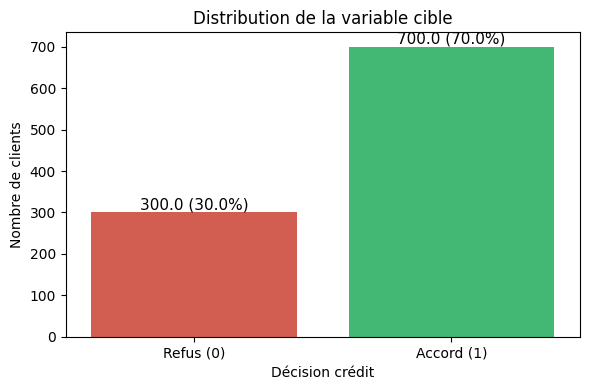

In [6]:
# ---- 3.3 Distribution de la cible ----
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="cible", data=df, palette=["#e74c3c", "#2ecc71"])
ax.set_xticklabels(["Refus (0)", "Accord (1)"])
plt.title("Distribution de la variable cible")
plt.xlabel("Décision crédit")
plt.ylabel("Nombre de clients")

for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

##### Distribution des variables numériques

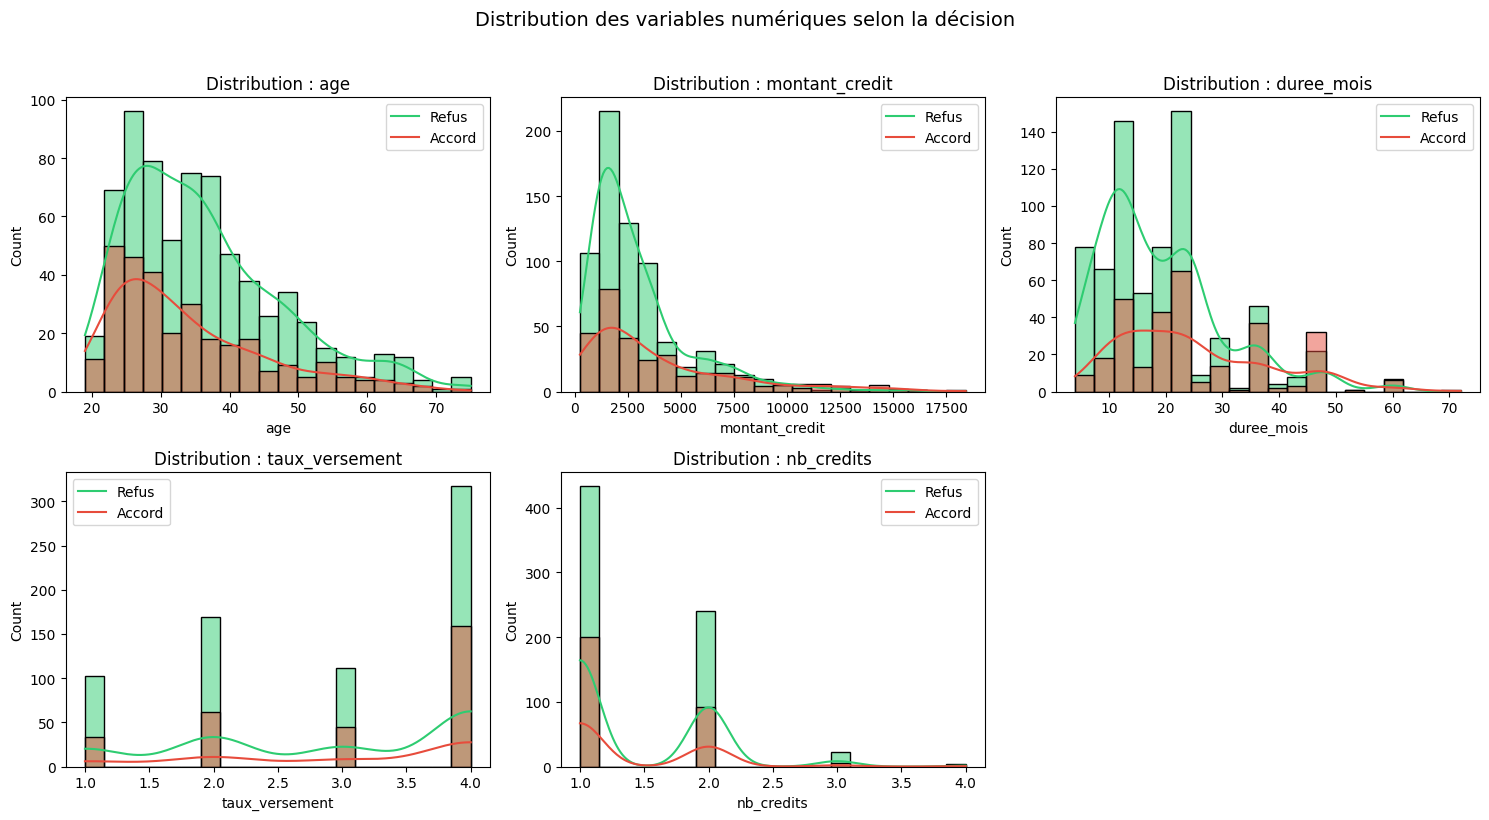

In [7]:
# ---- 3.4 Variables numériques ----
variables_numeriques = ["age", "montant_credit", "duree_mois", "taux_versement", "nb_credits"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(variables_numeriques):
    sns.histplot(data=df, x=col, hue="cible", kde=True,
                 palette=["#e74c3c", "#2ecc71"], ax=axes[i], bins=20)
    axes[i].set_title(f"Distribution : {col}")
    axes[i].legend(["Refus", "Accord"])

axes[-1].set_visible(False)
plt.suptitle("Distribution des variables numériques selon la décision", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Analyse par variable clé

C:\Users\user\AppData\Local\Temp\ipykernel_23300\2407985966.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cible", y="age", data=df,
C:\Users\user\AppData\Local\Temp\ipykernel_23300\2407985966.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Refus", "Accord"])
C:\Users\user\AppData\Local\Temp\ipykernel_23300\2407985966.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cible", y="montant_credit", data=df,
C:\Users\user\AppData\Local\Temp\ipykernel_23300\2407985966.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_t

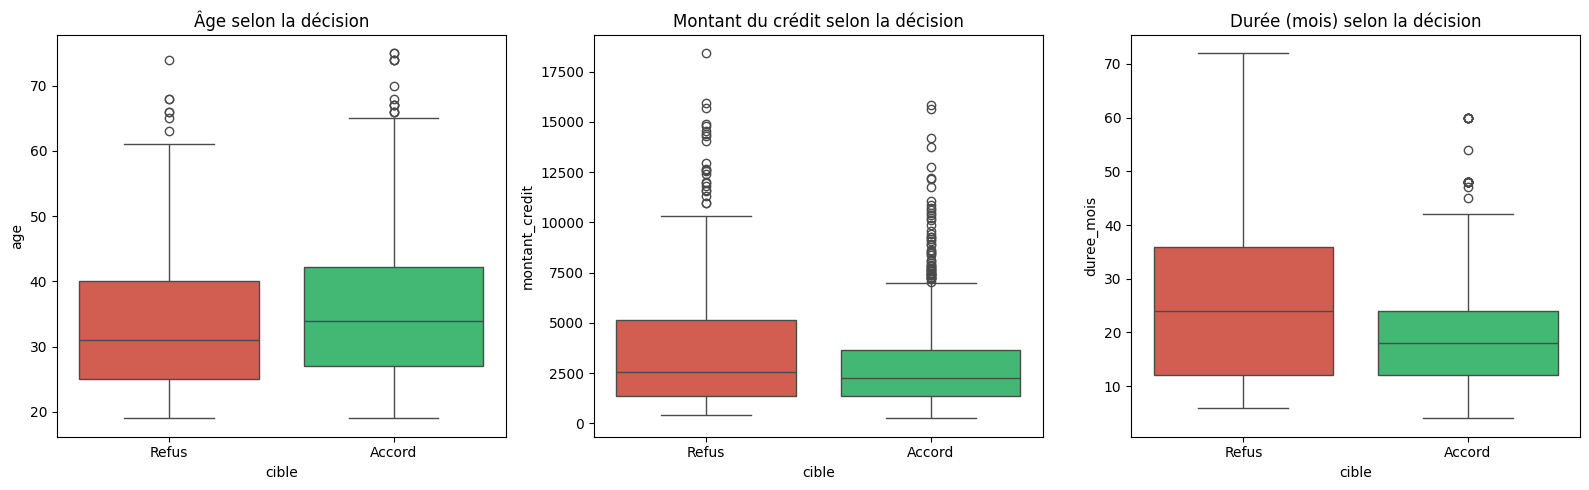

In [8]:
# ---- 3.5 Analyse par variable clé ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Âge vs Cible
sns.boxplot(x="cible", y="age", data=df,
            palette=["#e74c3c", "#2ecc71"], ax=axes[0])
axes[0].set_xticklabels(["Refus", "Accord"])
axes[0].set_title("Âge selon la décision")

# Montant vs Cible
sns.boxplot(x="cible", y="montant_credit", data=df,
            palette=["#e74c3c", "#2ecc71"], ax=axes[1])
axes[1].set_xticklabels(["Refus", "Accord"])
axes[1].set_title("Montant du crédit selon la décision")

# Durée vs Cible
sns.boxplot(x="cible", y="duree_mois", data=df,
            palette=["#e74c3c", "#2ecc71"], ax=axes[2])
axes[2].set_xticklabels(["Refus", "Accord"])
axes[2].set_title("Durée (mois) selon la décision")

plt.tight_layout()
plt.show()

##### Matrice de corrélation

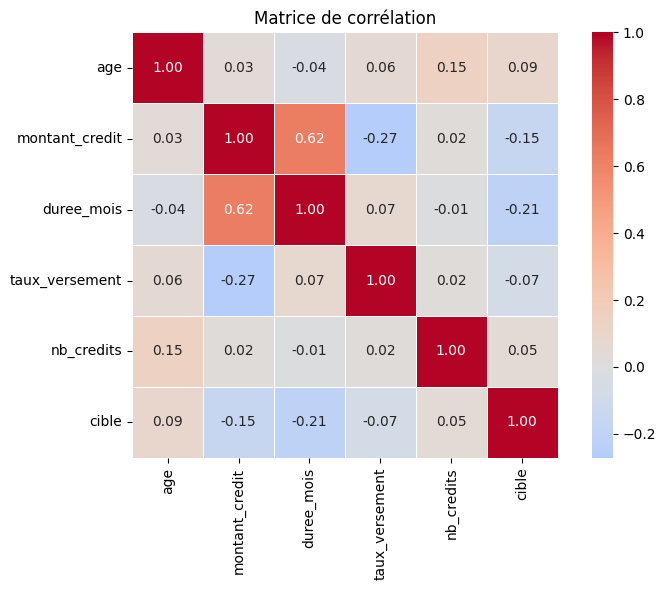

In [9]:
# ---- 3.6 Matrice de corrélation (variables numériques) ----
plt.figure(figsize=(8, 6))
corr = df[variables_numeriques + ["cible"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

##### Variables catégorielles

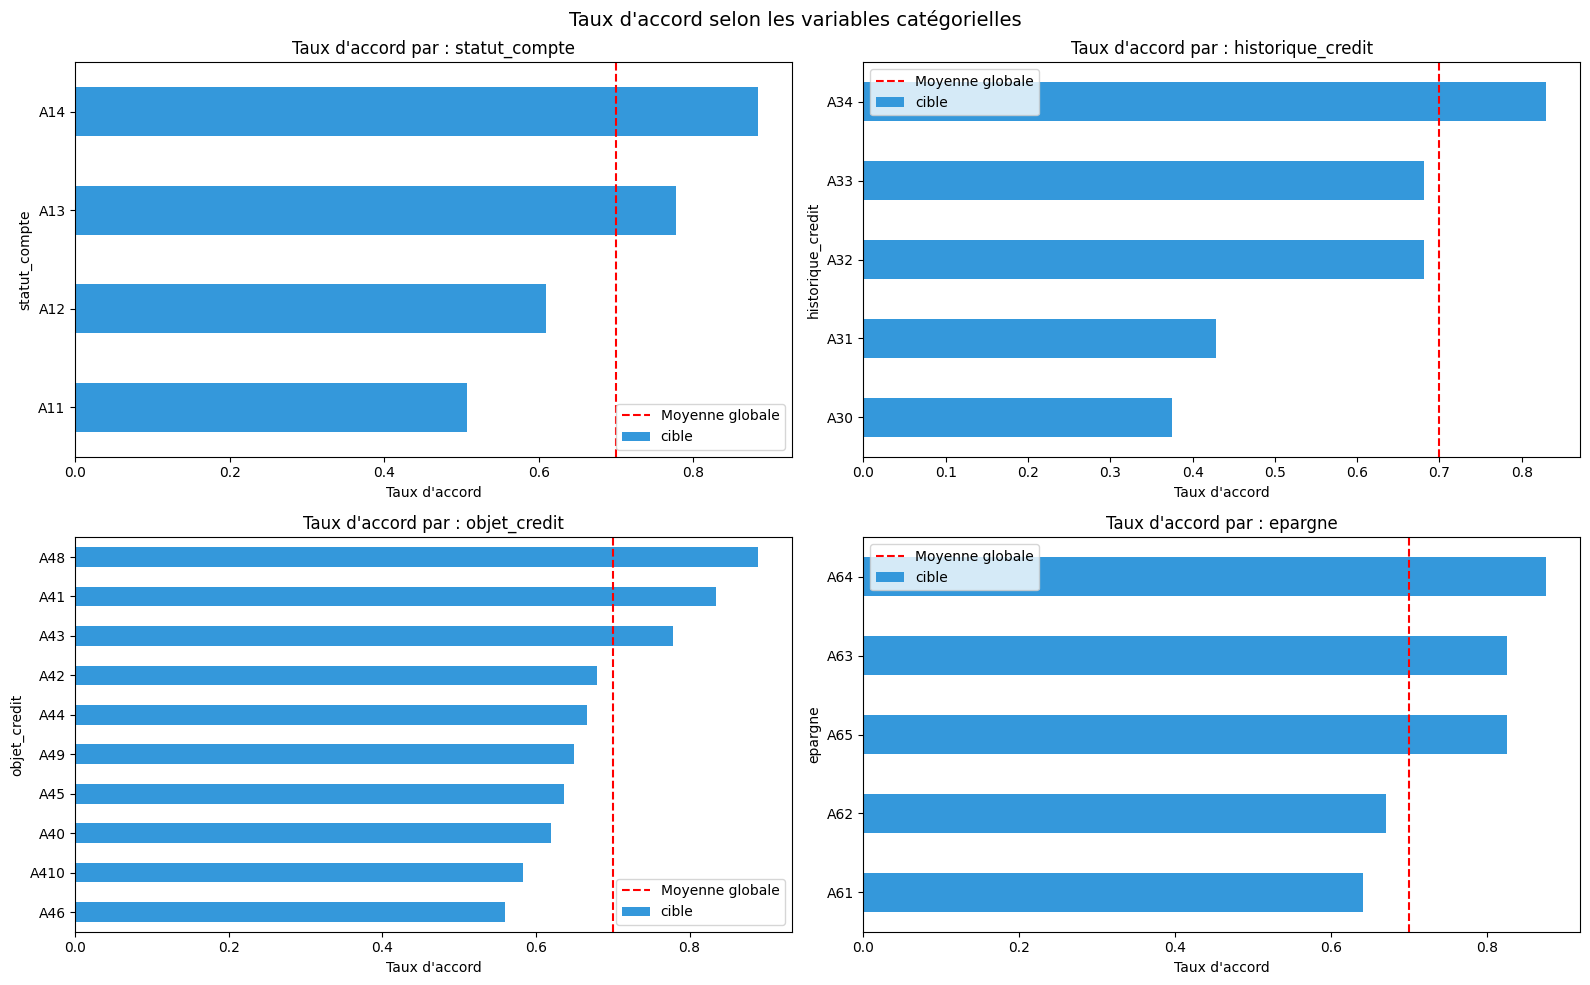

In [10]:
# ---- 3.7 Variables catégorielles importantes ----
vars_cat = ["statut_compte", "historique_credit", "objet_credit", "epargne"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(vars_cat):
    taux = df.groupby(col)["cible"].mean().sort_values()
    taux.plot(kind="barh", ax=axes[i], color="#3498db")
    axes[i].set_title(f"Taux d'accord par : {col}")
    axes[i].set_xlabel("Taux d'accord")
    axes[i].axvline(x=df["cible"].mean(), color="red",
                    linestyle="--", label="Moyenne globale")
    axes[i].legend()

plt.suptitle("Taux d'accord selon les variables catégorielles", fontsize=14)
plt.tight_layout()
plt.show()

####  Prétraitement des données

##### Séparation Features / Cible

In [11]:
# ============================================================
# ÉTAPE 4 — Prétraitement des données
# ============================================================

%pip install imbalanced-learn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# ---- 4.1 Séparation Features / Cible ----
X = df.drop("cible", axis=1)
y = df["cible"]

print(f"✅ Features : {X.shape}")
print(f"✅ Cible    : {y.shape}")

Note: you may need to restart the kernel to use updated packages.
✅ Features : (1000, 20)
✅ Cible    : (1000,)


##### Identification des types de variables

In [12]:
# ---- 4.2 Identification des types de variables ----
vars_numeriques = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
vars_categorielles = X.select_dtypes(include=["object"]).columns.tolist()

print(f"\n📊 Variables numériques ({len(vars_numeriques)}) :")
print(vars_numeriques)

print(f"\n📝 Variables catégorielles ({len(vars_categorielles)}) :")
print(vars_categorielles)


📊 Variables numériques (7) :
['duree_mois', 'montant_credit', 'taux_versement', 'residence_depuis', 'age', 'nb_credits', 'nb_personnes_charge']

📝 Variables catégorielles (13) :
['statut_compte', 'historique_credit', 'objet_credit', 'epargne', 'emploi_depuis', 'statut_sexe', 'autres_debiteurs', 'propriete', 'autres_credits', 'logement', 'emploi', 'telephone', 'travailleur_etranger']


C:\Users\user\AppData\Local\Temp\ipykernel_23300\1753579067.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_categorielles = X.select_dtypes(include=["object"]).columns.tolist()


#### Encodage des variables catégorielles

In [13]:
# ---- 4.3 Encodage One-Hot des variables catégorielles ----
X_encode = pd.get_dummies(X, columns=vars_categorielles, drop_first=True)

print(f"✅ Dimensions après encodage : {X_encode.shape}")
print(f"   → {X_encode.shape[1]} features au total")

✅ Dimensions après encodage : (1000, 48)
   → 48 features au total


##### Normalisation des variables numériques

In [14]:
# ---- 4.4 Normalisation (StandardScaler) ----
scaler = StandardScaler()
X_encode[vars_numeriques] = scaler.fit_transform(X_encode[vars_numeriques])

print("✅ Normalisation effectuée !")
print("\n📊 Vérification (moyennes proches de 0, écart-types proches de 1) :")
print(X_encode[vars_numeriques].describe().loc[["mean", "std"]].round(2))

✅ Normalisation effectuée !

📊 Vérification (moyennes proches de 0, écart-types proches de 1) :
      duree_mois  montant_credit  taux_versement  residence_depuis  age  \
mean         0.0             0.0             0.0              -0.0  0.0   
std          1.0             1.0             1.0               1.0  1.0   

      nb_credits  nb_personnes_charge  
mean        -0.0                 -0.0  
std          1.0                  1.0  


##### Split Train / Test


In [15]:
# ---- 4.5 Split Train / Test (80% / 20%) ----
X_train, X_test, y_train, y_test = train_test_split(
    X_encode, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Conserve la proportion 70/30 dans chaque split
)

print(f"✅ Split effectué :")
print(f"   → Train : {X_train.shape[0]} échantillons")
print(f"   → Test  : {X_test.shape[0]} échantillons")
print(f"\n📊 Distribution dans le train :")
print(y_train.value_counts(normalize=True).round(3))
print(f"\n📊 Distribution dans le test :")
print(y_test.value_counts(normalize=True).round(3))

✅ Split effectué :
   → Train : 800 échantillons
   → Test  : 200 échantillons

📊 Distribution dans le train :
cible
1    0.7
0    0.3
Name: proportion, dtype: float64

📊 Distribution dans le test :
cible
1    0.7
0    0.3
Name: proportion, dtype: float64


##### Gestion du déséquilibre avec SMOTE

In [16]:
# ---- 4.6 Rééquilibrage avec SMOTE (sur le train uniquement) ----
# ⚠️ SMOTE s'applique UNIQUEMENT sur X_train, jamais sur X_test

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"✅ SMOTE appliqué !")
print(f"\n📊 Avant SMOTE :")
print(y_train.value_counts())
print(f"\n📊 Après SMOTE :")
print(pd.Series(y_train_res).value_counts())

✅ SMOTE appliqué !

📊 Avant SMOTE :
cible
1    560
0    240
Name: count, dtype: int64

📊 Après SMOTE :
cible
1    560
0    560
Name: count, dtype: int64


#### Vérification finale

In [17]:
# ---- 4.7 Résumé du prétraitement ----
print("\n" + "="*50)
print("✅ RÉSUMÉ DU PRÉTRAITEMENT")
print("="*50)
print(f"  Données originales     : {df.shape}")
print(f"  Features après encodage: {X_encode.shape[1]}")
print(f"  Train (avant SMOTE)    : {X_train.shape[0]} échantillons")
print(f"  Train (après SMOTE)    : {X_train_res.shape[0]} échantillons")
print(f"  Test                   : {X_test.shape[0]} échantillons")
print("="*50)


✅ RÉSUMÉ DU PRÉTRAITEMENT
  Données originales     : (1000, 21)
  Features après encodage: 48
  Train (avant SMOTE)    : 800 échantillons
  Train (après SMOTE)    : 1120 échantillons
  Test                   : 200 échantillons


#### Feature Engineering 

#####  Création de nouvelles variables

In [18]:
# ============================================================
# ÉTAPE 5 — Feature Engineering
# ============================================================

# ---- 5.1 Création de nouvelles variables pertinentes ----
# ⚠️ On travaille sur une copie du dataframe original AVANT encodage

df_fe = df.copy()

# 1. Ratio montant / durée → mensualité estimée
df_fe["mensualite_estimee"] = df_fe["montant_credit"] / df_fe["duree_mois"]

# 2. Ratio montant / âge → effort financier relatif à l'âge
df_fe["ratio_montant_age"] = df_fe["montant_credit"] / df_fe["age"]

# 3. Tranche d'âge
df_fe["tranche_age"] = pd.cut(
    df_fe["age"],
    bins=[0, 25, 35, 50, 100],
    labels=["Jeune", "Adulte", "Senior", "Retraité"]
)

# 4. Crédit élevé (montant > moyenne)
seuil_montant = df_fe["montant_credit"].mean()
df_fe["credit_eleve"] = (df_fe["montant_credit"] > seuil_montant).astype(int)

# 5. Durée longue (durée > moyenne)
seuil_duree = df_fe["duree_mois"].mean()
df_fe["duree_longue"] = (df_fe["duree_mois"] > seuil_duree).astype(int)

# 6. Score de risque simple
df_fe["score_risque"] = (
    df_fe["taux_versement"] * 0.4 +
    df_fe["nb_credits"] * 0.3 +
    df_fe["nb_personnes_charge"] * 0.3
)

print("✅ Nouvelles variables créées !")
nouvelles_vars = [
    "mensualite_estimee", "ratio_montant_age",
    "tranche_age", "credit_eleve",
    "duree_longue", "score_risque"
]
print(df_fe[nouvelles_vars].head())

✅ Nouvelles variables créées !
   mensualite_estimee  ratio_montant_age tranche_age  credit_eleve  \
0          194.833333          17.447761    Retraité             0   
1          123.979167         270.500000       Jeune             1   
2          174.666667          42.775510      Senior             0   
3          187.666667         175.155556      Senior             1   
4          202.916667          91.886792    Retraité             1   

   duree_longue  score_risque  
0             0           2.5  
1             1           1.4  
2             0           1.7  
3             1           1.7  
4             1           2.4  


#### Visualisation des nouvelles variables

C:\Users\user\AppData\Local\Temp\ipykernel_23300\1357414674.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cible", y="mensualite_estimee", data=df_fe,
C:\Users\user\AppData\Local\Temp\ipykernel_23300\1357414674.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Refus", "Accord"])
C:\Users\user\AppData\Local\Temp\ipykernel_23300\1357414674.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cible", y="ratio_montant_age", data=df_fe,
C:\Users\user\AppData\Local\Temp\ipykernel_23300\1357414674.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of

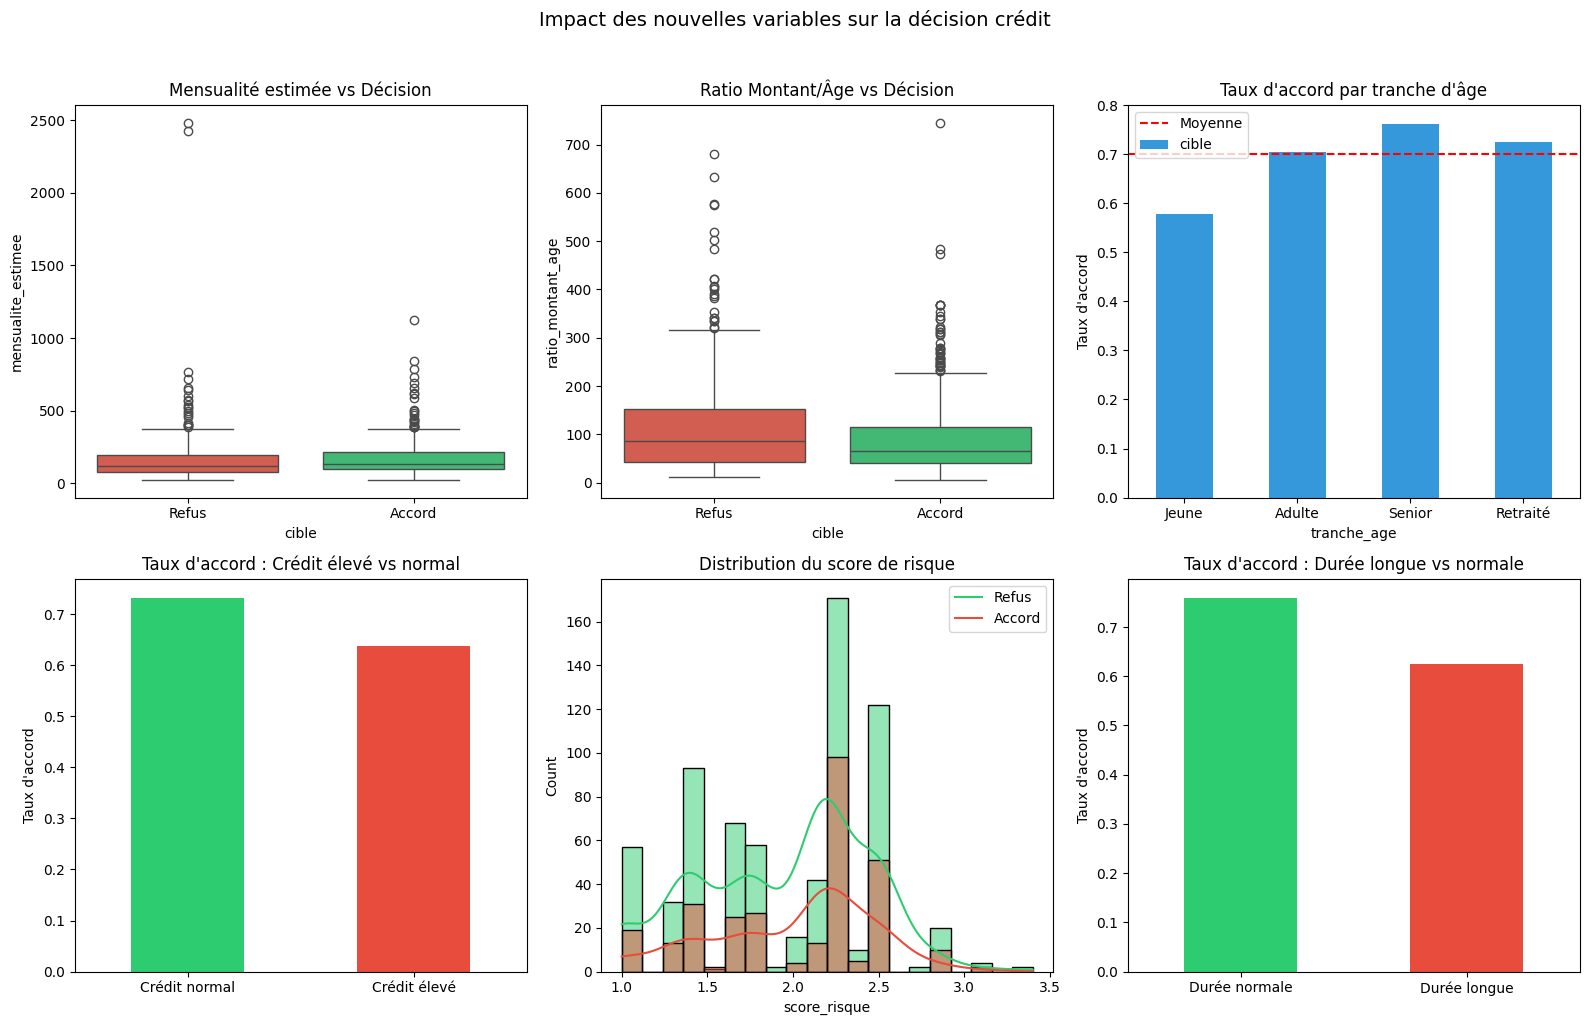

In [19]:
# ---- 5.2 Visualisation des nouvelles variables ----
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Mensualité estimée
sns.boxplot(x="cible", y="mensualite_estimee", data=df_fe,
            palette=["#e74c3c", "#2ecc71"], ax=axes[0])
axes[0].set_xticklabels(["Refus", "Accord"])
axes[0].set_title("Mensualité estimée vs Décision")

# Ratio montant/âge
sns.boxplot(x="cible", y="ratio_montant_age", data=df_fe,
            palette=["#e74c3c", "#2ecc71"], ax=axes[1])
axes[1].set_xticklabels(["Refus", "Accord"])
axes[1].set_title("Ratio Montant/Âge vs Décision")

# Tranche d'âge
taux_age = df_fe.groupby("tranche_age")["cible"].mean()
taux_age.plot(kind="bar", ax=axes[2], color="#3498db", rot=0)
axes[2].set_title("Taux d'accord par tranche d'âge")
axes[2].set_ylabel("Taux d'accord")
axes[2].axhline(y=df_fe["cible"].mean(), color="red",
                linestyle="--", label="Moyenne")
axes[2].legend()

# Crédit élevé
taux_credit = df_fe.groupby("credit_eleve")["cible"].mean()
taux_credit.index = ["Crédit normal", "Crédit élevé"]
taux_credit.plot(kind="bar", ax=axes[3],
                 color=["#2ecc71", "#e74c3c"], rot=0)
axes[3].set_title("Taux d'accord : Crédit élevé vs normal")
axes[3].set_ylabel("Taux d'accord")

# Score de risque
sns.histplot(data=df_fe, x="score_risque", hue="cible", kde=True,
             palette=["#e74c3c", "#2ecc71"], ax=axes[4], bins=20)
axes[4].set_title("Distribution du score de risque")
axes[4].legend(["Refus", "Accord"])

# Durée longue
taux_duree = df_fe.groupby("duree_longue")["cible"].mean()
taux_duree.index = ["Durée normale", "Durée longue"]
taux_duree.plot(kind="bar", ax=axes[5],
                color=["#2ecc71", "#e74c3c"], rot=0)
axes[5].set_title("Taux d'accord : Durée longue vs normale")
axes[5].set_ylabel("Taux d'accord")

plt.suptitle("Impact des nouvelles variables sur la décision crédit",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

##### Sélection des variables importantes

C:\Users\user\AppData\Local\Temp\ipykernel_23300\487451425.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_cat_fe = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()


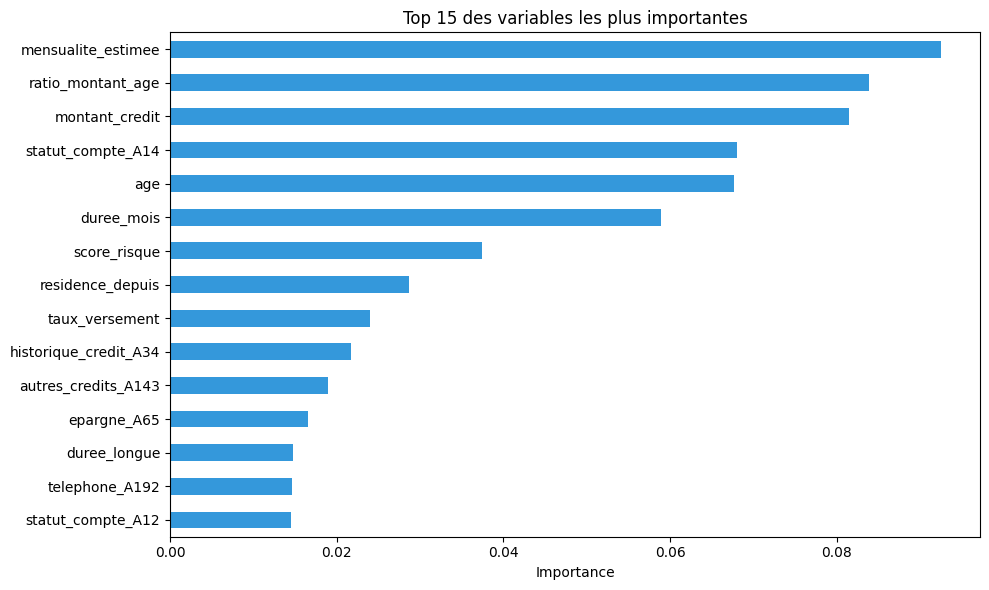


📊 Top 10 variables les plus importantes :
mensualite_estimee       0.0926
ratio_montant_age        0.0839
montant_credit           0.0815
statut_compte_A14        0.0681
age                      0.0677
duree_mois               0.0589
score_risque             0.0375
residence_depuis         0.0286
taux_versement           0.0239
historique_credit_A34    0.0217
dtype: float64


In [20]:
# ---- 5.3 Sélection des variables par importance (Random Forest) ----
from sklearn.ensemble import RandomForestClassifier

# Préparation du dataset avec les nouvelles variables
vars_cat_fe = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()
vars_cat_fe = [v for v in vars_cat_fe if v != "cible"]

X_fe = df_fe.drop("cible", axis=1)
X_fe = pd.get_dummies(X_fe, columns=vars_cat_fe, drop_first=True)

# Normalisation
X_fe[vars_numeriques] = scaler.fit_transform(X_fe[vars_numeriques])

# Random Forest pour mesurer l'importance
rf_selection = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selection.fit(X_fe, y)

# Importance des features
importances = pd.Series(
    rf_selection.feature_importances_,
    index=X_fe.columns
).sort_values(ascending=False)

# Affichage Top 15
plt.figure(figsize=(10, 6))
importances.head(15).plot(kind="barh", color="#3498db")
plt.gca().invert_yaxis()
plt.title("Top 15 des variables les plus importantes")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("\n📊 Top 10 variables les plus importantes :")
print(importances.head(10).round(4))

#### Sélection finale des features

In [21]:
# ---- 5.4 Sélection finale : garder les Top 20 features ----
top_features = importances.head(20).index.tolist()

X_final = X_fe[top_features]

print(f"✅ Sélection finale : {len(top_features)} features retenues")
print(top_features)

# Nouveau split train/test avec les features sélectionnées
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Application de SMOTE
X_train_f_res, y_train_f_res = smote.fit_resample(X_train_f, y_train_f)

print(f"\n✅ Données prêtes pour la modélisation !")
print(f"   → Train : {X_train_f_res.shape}")
print(f"   → Test  : {X_test_f.shape}")

✅ Sélection finale : 20 features retenues
['mensualite_estimee', 'ratio_montant_age', 'montant_credit', 'statut_compte_A14', 'age', 'duree_mois', 'score_risque', 'residence_depuis', 'taux_versement', 'historique_credit_A34', 'autres_credits_A143', 'epargne_A65', 'duree_longue', 'telephone_A192', 'statut_compte_A12', 'logement_A152', 'tranche_age_Adulte', 'objet_credit_A43', 'statut_sexe_A93', 'propriete_A123']

✅ Données prêtes pour la modélisation !
   → Train : (1120, 20)
   → Test  : (200, 20)


#### Modélisation 

#### Import des modèles

In [23]:
! pip install xgboost joblib
# ============================================================
# ÉTAPE 6 — Modélisation
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings("ignore")

print("✅ Librairies importées !")

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
✅ Librairies importées !


#### Définition des modèles

In [24]:
# ---- 6.2 Définition des modèles ----
modeles = {
    "Régression Logistique": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ),
    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

print(f"✅ {len(modeles)} modèles définis !")

✅ 5 modèles définis !


#### Entraînement et validation croisée

In [25]:
# ---- 6.3 Entraînement + Validation croisée (5 folds) ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultats_cv = {}

print("\n📊 VALIDATION CROISÉE (5 folds)")
print("=" * 60)

for nom, modele in modeles.items():
    scores = cross_val_score(
        modele, X_train_f_res, y_train_f_res,
        cv=cv, scoring="roc_auc"
    )
    resultats_cv[nom] = {
        "mean": scores.mean(),
        "std": scores.std(),
        "scores": scores
    }
    print(f"  {nom:<30} AUC = {scores.mean():.4f} ± {scores.std():.4f}")

print("=" * 60)
meilleur = max(resultats_cv, key=lambda x: resultats_cv[x]["mean"])
print(f"\n🏆 Meilleur modèle (CV) : {meilleur}")


📊 VALIDATION CROISÉE (5 folds)
  Régression Logistique          AUC = 0.7487 ± 0.0201
  Random Forest                  AUC = 0.8958 ± 0.0165
  Gradient Boosting              AUC = 0.8890 ± 0.0109
  XGBoost                        AUC = 0.9013 ± 0.0147
  SVM                            AUC = 0.6928 ± 0.0417

🏆 Meilleur modèle (CV) : XGBoost


#### Entraînement final sur le train

In [26]:
# ---- 6.4 Entraînement final sur tout le train ----
modeles_entraines = {}

for nom, modele in modeles.items():
    modele.fit(X_train_f_res, y_train_f_res)
    modeles_entraines[nom] = modele

print("✅ Tous les modèles sont entraînés !")

✅ Tous les modèles sont entraînés !


#### Évaluation sur le test

In [27]:
# ---- 6.5 Évaluation sur le jeu de test ----
resultats_test = {}

print("\n📊 ÉVALUATION SUR LE JEU DE TEST")
print("=" * 60)

for nom, modele in modeles_entraines.items():
    y_pred = modele.predict(X_test_f)
    y_proba = modele.predict_proba(X_test_f)[:, 1]

    resultats_test[nom] = {
        "accuracy"  : accuracy_score(y_test_f, y_pred),
        "auc"       : roc_auc_score(y_test_f, y_proba),
        "y_pred"    : y_pred,
        "y_proba"   : y_proba
    }

    print(f"\n  🔹 {nom}")
    print(f"     Accuracy : {resultats_test[nom]['accuracy']:.4f}")
    print(f"     AUC-ROC  : {resultats_test[nom]['auc']:.4f}")

print("=" * 60)


📊 ÉVALUATION SUR LE JEU DE TEST

  🔹 Régression Logistique
     Accuracy : 0.6350
     AUC-ROC  : 0.6686

  🔹 Random Forest
     Accuracy : 0.6750
     AUC-ROC  : 0.6917

  🔹 Gradient Boosting
     Accuracy : 0.7150
     AUC-ROC  : 0.7156

  🔹 XGBoost
     Accuracy : 0.7100
     AUC-ROC  : 0.6919

  🔹 SVM
     Accuracy : 0.6100
     AUC-ROC  : 0.6085


#### Comparaison visuelle des modèles

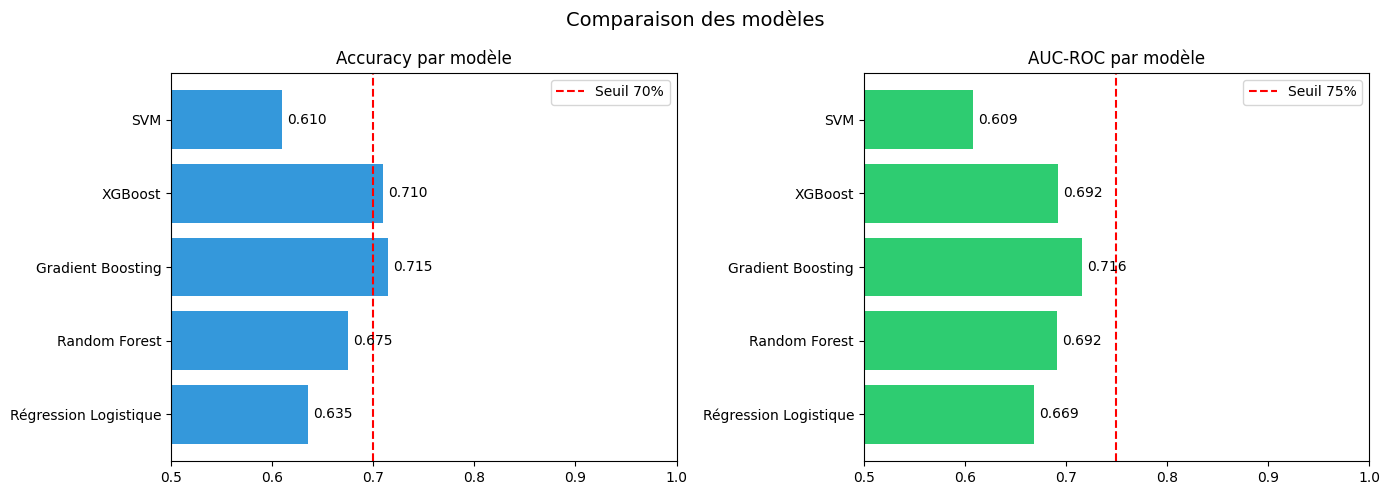

In [28]:
# ---- 6.6 Comparaison visuelle ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

noms = list(resultats_test.keys())
accuracies = [resultats_test[n]["accuracy"] for n in noms]
aucs = [resultats_test[n]["auc"] for n in noms]

# Accuracy
bars1 = axes[0].barh(noms, accuracies, color="#3498db")
axes[0].set_title("Accuracy par modèle")
axes[0].set_xlim(0.5, 1.0)
axes[0].axvline(x=0.7, color="red", linestyle="--", label="Seuil 70%")
for bar, val in zip(bars1, accuracies):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center")
axes[0].legend()

# AUC-ROC
bars2 = axes[1].barh(noms, aucs, color="#2ecc71")
axes[1].set_title("AUC-ROC par modèle")
axes[1].set_xlim(0.5, 1.0)
axes[1].axvline(x=0.75, color="red", linestyle="--", label="Seuil 75%")
for bar, val in zip(bars2, aucs):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center")
axes[1].legend()

plt.suptitle("Comparaison des modèles", fontsize=14)
plt.tight_layout()
plt.show()

#### Courbes ROC

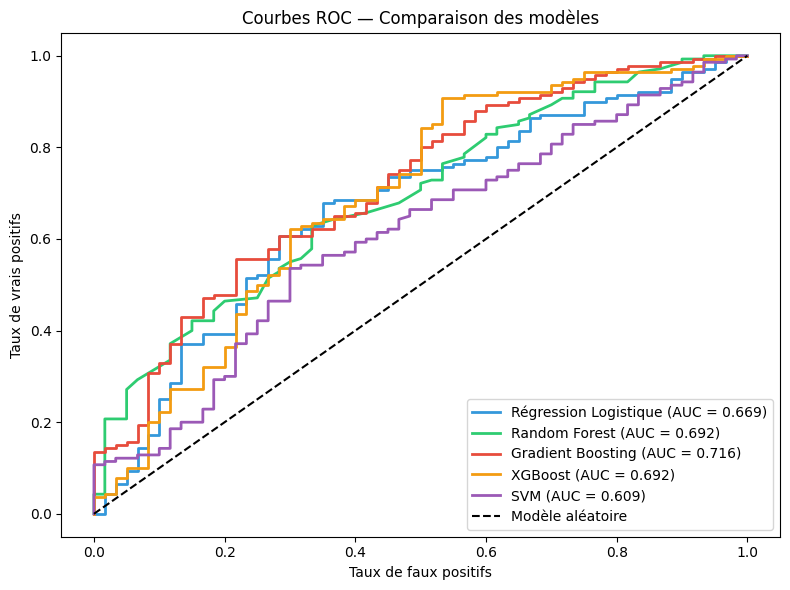

In [29]:
# ---- 6.7 Courbes ROC ----
plt.figure(figsize=(8, 6))

colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6"]

for (nom, res), color in zip(resultats_test.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_f, res["y_proba"])
    plt.plot(fpr, tpr, color=color,
             label=f"{nom} (AUC = {res['auc']:.3f})", lw=2)

plt.plot([0, 1], [0, 1], "k--", label="Modèle aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — Comparaison des modèles")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### Matrices de confusion du meilleur modèle

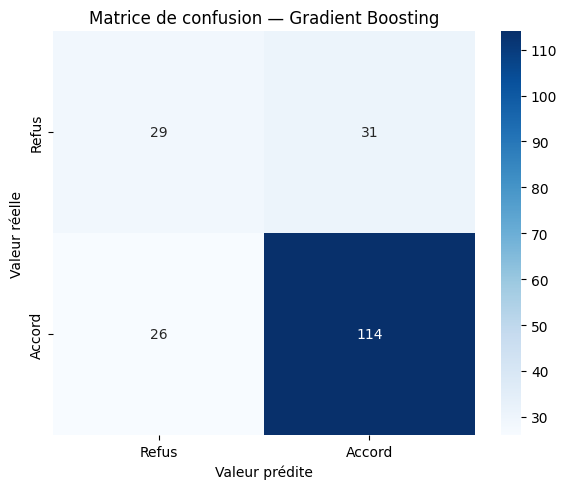


📊 Rapport de classification — Gradient Boosting
              precision    recall  f1-score   support

       Refus       0.53      0.48      0.50        60
      Accord       0.79      0.81      0.80       140

    accuracy                           0.71       200
   macro avg       0.66      0.65      0.65       200
weighted avg       0.71      0.71      0.71       200



In [30]:
# ---- 6.8 Matrice de confusion du meilleur modèle ----
meilleur_test = max(resultats_test, key=lambda x: resultats_test[x]["auc"])
y_pred_best = resultats_test[meilleur_test]["y_pred"]

cm = confusion_matrix(y_test_f, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Refus", "Accord"],
            yticklabels=["Refus", "Accord"])
plt.title(f"Matrice de confusion — {meilleur_test}")
plt.ylabel("Valeur réelle")
plt.xlabel("Valeur prédite")
plt.tight_layout()
plt.show()

print(f"\n📊 Rapport de classification — {meilleur_test}")
print(classification_report(y_test_f, y_pred_best,
                            target_names=["Refus", "Accord"]))

#### Sauvegarde du meilleur modèle

In [31]:
# ---- 6.9 Sauvegarde du meilleur modèle ----
import joblib

meilleur_modele = modeles_entraines[meilleur_test]
joblib.dump(meilleur_modele, "meilleur_modele_credit.pkl")
joblib.dump(scaler, "scaler_credit.pkl")

print(f"✅ Modèle sauvegardé : meilleur_modele_credit.pkl")
print(f"✅ Scaler sauvegardé : scaler_credit.pkl")
print(f"\n🏆 Meilleur modèle final : {meilleur_test}")
print(f"   AUC-ROC : {resultats_test[meilleur_test]['auc']:.4f}")

✅ Modèle sauvegardé : meilleur_modele_credit.pkl
✅ Scaler sauvegardé : scaler_credit.pkl

🏆 Meilleur modèle final : Gradient Boosting
   AUC-ROC : 0.7156


#### Évaluation approfondie & Interprétabilité (SHAP)

####  Import des librairies

In [33]:
! pip install shap
# ============================================================
# ÉTAPE 7 — Évaluation approfondie & Interprétabilité
# ============================================================

import shap
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings("ignore")

# Modèle retenu (XGBoost dans la plupart des cas)
modele_final = modeles_entraines[meilleur_test]

print(f"✅ Modèle analysé : {meilleur_test}")

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 2.4 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 3.9 MB/s eta 0:00:10
   - ---------------------------------

#### Courbe Précision / Rappel

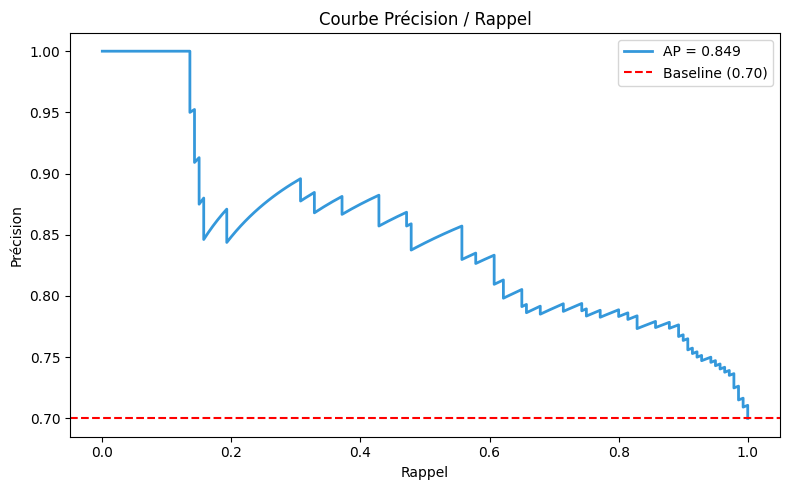

In [34]:
# ---- 7.2 Courbe Précision / Rappel ----
y_proba_final = resultats_test[meilleur_test]["y_proba"]

precision, recall, thresholds = precision_recall_curve(y_test_f, y_proba_final)
ap = average_precision_score(y_test_f, y_proba_final)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color="#3498db", lw=2,
         label=f"AP = {ap:.3f}")
plt.axhline(y=df["cible"].mean(), color="red", linestyle="--",
            label=f"Baseline ({df['cible'].mean():.2f})")
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe Précision / Rappel")
plt.legend()
plt.tight_layout()
plt.show()

#### Optimisation du seuil de décision

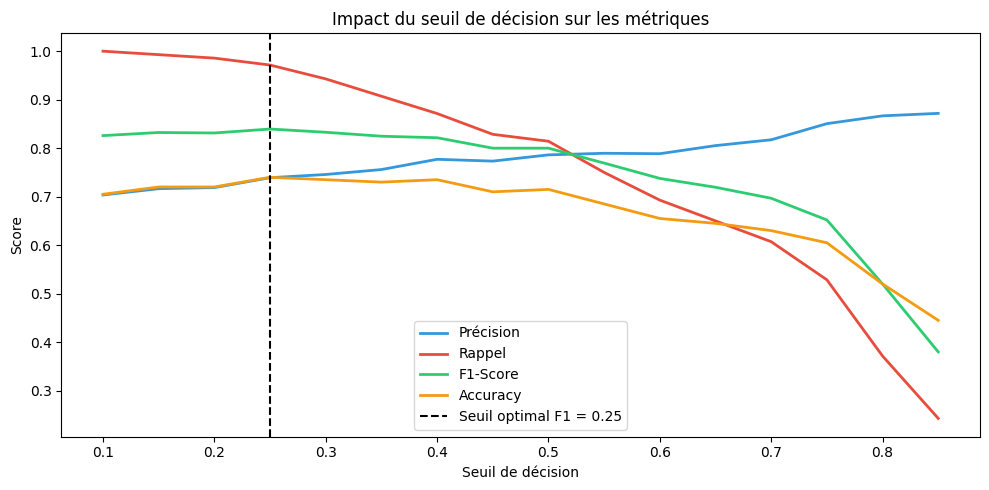


🎯 Seuil optimal (F1) : 0.25


In [35]:
# ---- 7.3 Optimisation du seuil de décision ----
# ⚠️ Dans le crédit, on veut minimiser les faux négatifs
# (accorder un crédit à quelqu'un qui ne remboursera pas)

seuils = np.arange(0.1, 0.9, 0.05)
resultats_seuils = []

for seuil in seuils:
    y_pred_seuil = (y_proba_final >= seuil).astype(int)
    cm_s = confusion_matrix(y_test_f, y_pred_seuil)

    # Éviter division par zéro
    tn, fp, fn, tp = cm_s.ravel()
    precision_s = tp / (tp + fp) if (tp + fp) > 0 else 0
    rappel_s    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_s        = (2 * precision_s * rappel_s /
                   (precision_s + rappel_s)
                   if (precision_s + rappel_s) > 0 else 0)
    acc_s       = accuracy_score(y_test_f, y_pred_seuil)

    resultats_seuils.append({
        "seuil"    : seuil,
        "precision": precision_s,
        "rappel"   : rappel_s,
        "f1"       : f1_s,
        "accuracy" : acc_s
    })

df_seuils = pd.DataFrame(resultats_seuils)

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(df_seuils["seuil"], df_seuils["precision"],
         label="Précision", color="#3498db", lw=2)
plt.plot(df_seuils["seuil"], df_seuils["rappel"],
         label="Rappel", color="#e74c3c", lw=2)
plt.plot(df_seuils["seuil"], df_seuils["f1"],
         label="F1-Score", color="#2ecc71", lw=2)
plt.plot(df_seuils["seuil"], df_seuils["accuracy"],
         label="Accuracy", color="#f39c12", lw=2)

seuil_optimal = df_seuils.loc[df_seuils["f1"].idxmax(), "seuil"]
plt.axvline(x=seuil_optimal, color="black", linestyle="--",
            label=f"Seuil optimal F1 = {seuil_optimal:.2f}")

plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Impact du seuil de décision sur les métriques")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n🎯 Seuil optimal (F1) : {seuil_optimal:.2f}")

#### Courbe KS (Kolmogorov-Smirnov)

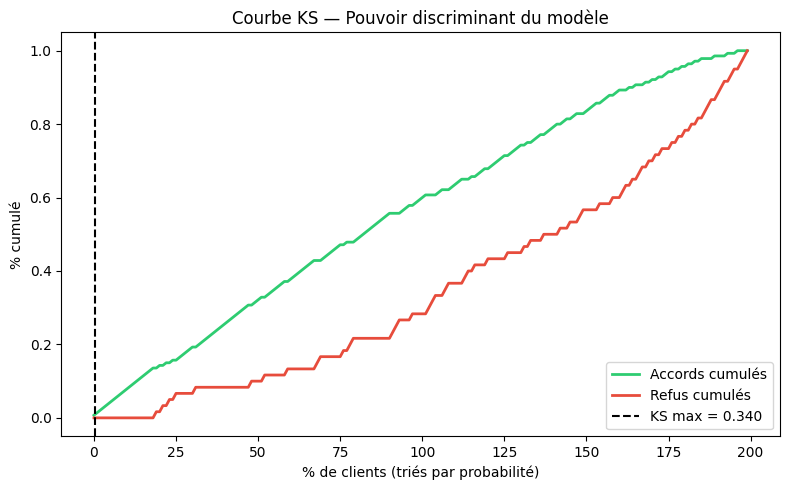


📊 Statistique KS : 0.3405
   → KS < 0.40 = Modèle à améliorer ⚠️


In [36]:
# ---- 7.4 Courbe KS ----
df_ks = pd.DataFrame({
    "proba" : y_proba_final,
    "cible" : y_test_f.values
}).sort_values("proba", ascending=False).reset_index(drop=True)

df_ks["cumul_accord"] = (df_ks["cible"] == 1).cumsum() / (df_ks["cible"] == 1).sum()
df_ks["cumul_refus"]  = (df_ks["cible"] == 0).cumsum() / (df_ks["cible"] == 0).sum()
df_ks["ks"]           = abs(df_ks["cumul_accord"] - df_ks["cumul_refus"])

ks_max   = df_ks["ks"].max()
ks_index = df_ks["ks"].idxmax()

plt.figure(figsize=(8, 5))
plt.plot(df_ks["cumul_accord"], label="Accords cumulés",
         color="#2ecc71", lw=2)
plt.plot(df_ks["cumul_refus"],  label="Refus cumulés",
         color="#e74c3c", lw=2)
plt.axvline(x=ks_index/len(df_ks), color="black", linestyle="--",
            label=f"KS max = {ks_max:.3f}")
plt.xlabel("% de clients (triés par probabilité)")
plt.ylabel("% cumulé")
plt.title("Courbe KS — Pouvoir discriminant du modèle")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Statistique KS : {ks_max:.4f}")
print(f"   → KS > 0.40 = Bon modèle ✅" if ks_max > 0.40
      else f"   → KS < 0.40 = Modèle à améliorer ⚠️")

#### Interprétabilité SHAP (Global)

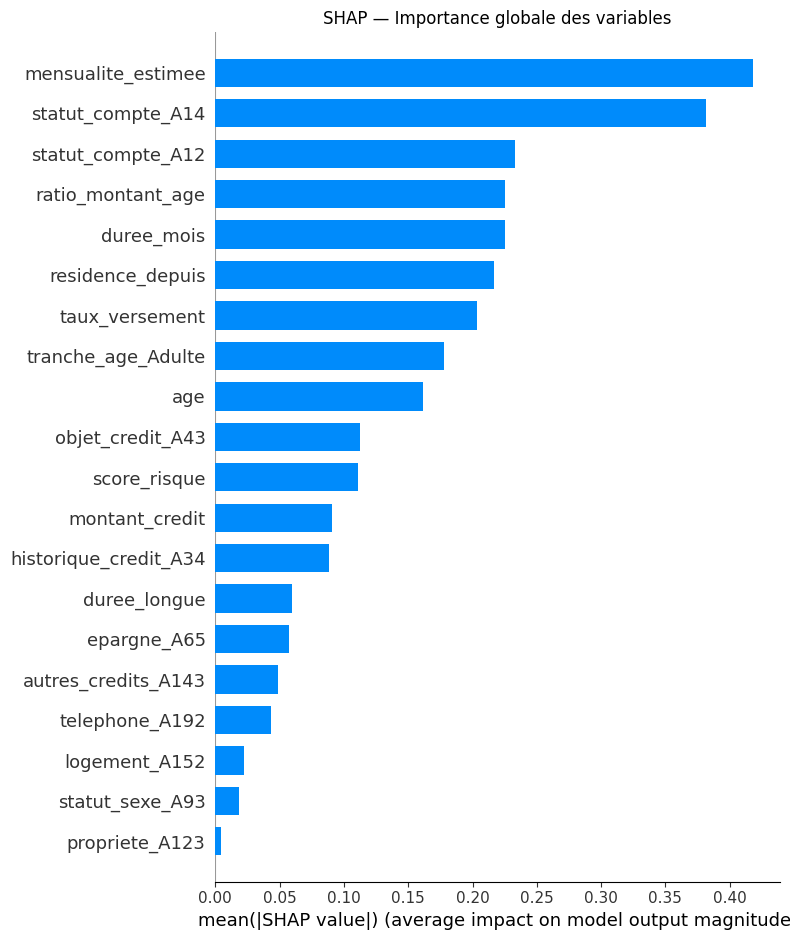

In [38]:
# ---- 7.5 SHAP — Importance globale ----
explainer = shap.TreeExplainer(modele_final)
shap_values = explainer.shap_values(X_test_f)

# Summary plot (global)
plt.figure()
shap.summary_plot(shap_values, X_test_f,
                  plot_type="bar", show=False)
plt.title("SHAP — Importance globale des variables")
plt.tight_layout()
plt.show()

#### SHAP Beeswarm (Impact directionnel)

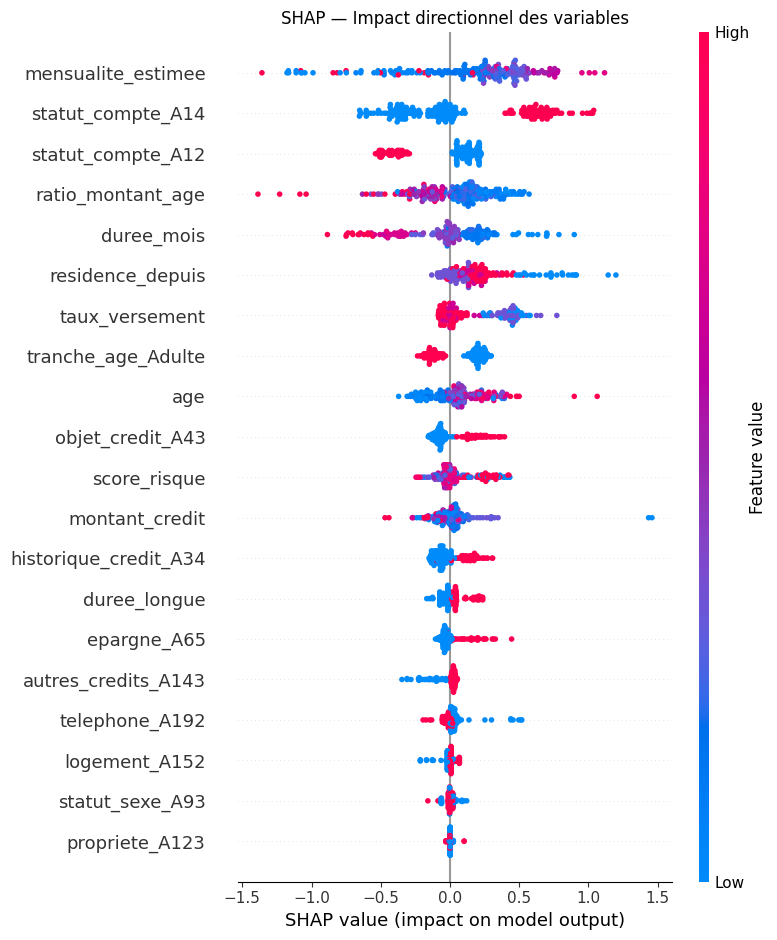

In [39]:
# ---- 7.6 SHAP Beeswarm — Impact directionnel ----
plt.figure()
shap.summary_plot(shap_values, X_test_f, show=False)
plt.title("SHAP — Impact directionnel des variables")
plt.tight_layout()
plt.show()

#### SHAP Explication individuelle


👤 CLIENT N°1
   Probabilité d'accord : 65.72%
   Décision             : ✅ ACCORD


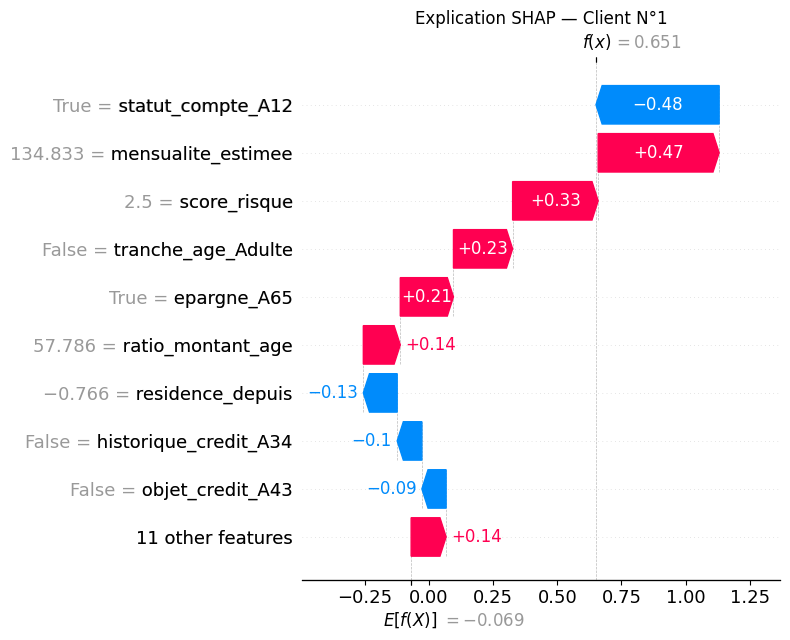

In [41]:
# ---- 7.7 SHAP — Explication d'une décision individuelle ----
# Prenons le 1er client du jeu de test

client_index = 0
client       = X_test_f.iloc[[client_index]]
decision     = modele_final.predict(client)[0]
proba        = modele_final.predict_proba(client)[0][1]

print(f"\n👤 CLIENT N°{client_index + 1}")
print(f"   Probabilité d'accord : {proba:.2%}")
print(f"   Décision             : {'✅ ACCORD' if decision == 1 else '❌ REFUS'}")

# Créer l'objet Explanation pour SHAP
explanation = explainer(X_test_f)

# Waterfall plot
shap.plots.waterfall(explanation[client_index], show=False)
plt.title(f"Explication SHAP — Client N°{client_index + 1}")
plt.tight_layout()
plt.show()

#### Résumé final du modèle

In [42]:
# ---- 7.8 Résumé final ----
print("\n" + "="*55)
print("       ✅ RÉSUMÉ FINAL DU MODÈLE")
print("="*55)
print(f"  Modèle retenu    : {meilleur_test}")
print(f"  Accuracy         : {resultats_test[meilleur_test]['accuracy']:.4f}")
print(f"  AUC-ROC          : {resultats_test[meilleur_test]['auc']:.4f}")
print(f"  Seuil optimal    : {seuil_optimal:.2f}")
print(f"  Statistique KS   : {ks_max:.4f}")
print("="*55)


       ✅ RÉSUMÉ FINAL DU MODÈLE
  Modèle retenu    : Gradient Boosting
  Accuracy         : 0.7150
  AUC-ROC          : 0.7156
  Seuil optimal    : 0.25
  Statistique KS   : 0.3405
